In [ ]:
!pip install ultralytics pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 974.8/974.8 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [ ]:
import torch
import cv2
import numpy as np
from PIL import Image
from ultralytics import YOLO
from transformers import DPTForDepthEstimation, DPTFeatureExtractor

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import json
from PIL import Image

def coco_to_yolo_bbox(bbox, img_w, img_h):
    x_min, y_min, width, height = bbox
    x_center = (x_min + width / 2) / img_w
    y_center = (y_min + height / 2) / img_h
    width /= img_w
    height /= img_h
    return [x_center, y_center, width, height]

def convert_annotations(json_path, image_dir, label_dir):
    os.makedirs(label_dir, exist_ok=True)

    with open(json_path) as f:
        data = json.load(f)

    image_id_to_filename = {img['id']: img['file_name'] for img in data['images']}
    categories = data['categories']
    category_id_map = {cat['id']: idx for idx, cat in enumerate(categories)}  # remap to 0-indexed
    class_names = [cat['name'] for cat in categories]

    image_sizes = {}
    for image in data['images']:
        try:
            with Image.open(os.path.join(image_dir, image['file_name'])) as img:
                image_sizes[image['id']] = img.size
        except:
            continue

    for ann in data['annotations']:
        image_id = ann['image_id']
        if image_id not in image_id_to_filename or image_id not in image_sizes:
            continue

        filename = image_id_to_filename[image_id]
        w, h = image_sizes[image_id]
        yolo_bbox = coco_to_yolo_bbox(ann['bbox'], w, h)
        class_id = category_id_map[ann['category_id']]

        label_path = os.path.join(label_dir, os.path.splitext(filename)[0] + ".txt")
        with open(label_path, "a") as f:
            f.write(f"{class_id} {' '.join(map(str, yolo_bbox))}\n")


    return len(class_names), class_names


In [ ]:
# from ultralytics import YOLO

image_dir = "/content/drive/MyDrive/vizwiz/images"
json_path = "/content/drive/MyDrive/vizwiz/base_annotations.json"
label_dir = "/content/drive/MyDrive/vizwiz/labels"

# Convert annotations and get class names
num_classes, class_names = convert_annotations(json_path, image_dir, label_dir)

In [ ]:
import yaml

data_yaml = {
    'train': "/content/drive/MyDrive/vizwiz/images",  # your full dataset
    'val': "/content/drive/MyDrive/vizwiz/images",    # same as train
    'nc': num_classes,
    'names': class_names
}

with open("vizwiz.yaml", "w") as f:
    yaml.dump(data_yaml, f)


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov9c.pt")
model.train(
    data="vizwiz.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    name="vizwiz_yolov9_noval"
)


100%|██████████| 49.4M/49.4M [00:00<00:00, 114MB/s]


Ultralytics 8.3.109 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov9c.pt, data=vizwiz.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=vizwiz_yolov9_noval, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, line_width=N

100%|██████████| 755k/755k [00:00<00:00, 22.2MB/s]


Overriding model.yaml nc=80 with nc=100

                   from  n    params  module                                       arguments                     
  0                  -1  1      1856  ultralytics.nn.modules.conv.Conv             [3, 64, 3, 2]                 
  1                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  2                  -1  1    212864  ultralytics.nn.modules.block.RepNCSPELAN4    [128, 256, 128, 64, 1]        
  3                  -1  1    164352  ultralytics.nn.modules.block.ADown           [256, 256]                    
  4                  -1  1    847616  ultralytics.nn.modules.block.RepNCSPELAN4    [256, 512, 256, 128, 1]       
  5                  -1  1    656384  ultralytics.nn.modules.block.ADown           [512, 512]                    
  6                  -1  1   2857472  ultralytics.nn.modules.block.RepNCSPELAN4    [512, 512, 512, 256, 1]       
  7                  -1  1    656384  ultralyti

100%|██████████| 5.35M/5.35M [00:00<00:00, 86.5MB/s]


...

      10/10      10.6G     0.5027      1.326      1.072          2        640: 100%|██████████| 259/259 [03:41<00:00,  1.17it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 130/130 [01:40<00:00,  1.29it/s]


                   all       4130       7822       0.79      0.653      0.745       0.67

10 epochs completed in 1.138 hours.
Optimizer stripped from runs/detect/vizwiz_yolov9_noval/weights/last.pt, 51.7MB
Optimizer stripped from runs/detect/vizwiz_yolov9_noval/weights/best.pt, 51.7MB

Validating runs/detect/vizwiz_yolov9_noval/weights/best.pt...
Ultralytics 8.3.109 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv9c summary (fused): 156 layers, 25,396,348 parameters, 0 gradients, 102.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 130/130 [01:42<00:00,  1.26it/s]


                   all       4130       7822      0.791      0.653      0.745       0.67
                banana         28         48      0.684       0.75      0.791      0.674
           ceiling_fan         24         25      0.714       0.76      0.801      0.761
        computer_mouse        103        103      0.893      0.728      0.868      0.825
          electric_fan         49         49      0.803      0.531      0.628      0.525
                   key         28         49      0.832      0.404      0.538      0.427
     computer_keyboard        326        337      0.838      0.785      0.858      0.811
                laptop        464        474       0.78      0.734      0.789      0.755
             microwave         57         57       0.78      0.421      0.551      0.508
               monitor        319        328       0.73      0.768      0.821      0.759
                   pen        118        147      0.804      0.721      0.804      0.682
               perfum

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77,
       78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78125d4b7a10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018, 

In [ ]:
# -------------------------------
# 2. Load MiDaS model
# -------------------------------
depth_model = DPTForDepthEstimation.from_pretrained("Intel/dpt-large")
depth_feature_extractor = DPTFeatureExtractor.from_pretrained("Intel/dpt-large")
depth_model.eval().to("cuda" if torch.cuda.is_available() else "cpu")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/942 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.37G [00:00<?, ?B/s]

Some weights of DPTForDepthEstimation were not initialized from the model checkpoint at Intel/dpt-large and are newly initialized: ['neck.fusion_stage.layers.0.residual_layer1.convolution1.bias', 'neck.fusion_stage.layers.0.residual_layer1.convolution1.weight', 'neck.fusion_stage.layers.0.residual_layer1.convolution2.bias', 'neck.fusion_stage.layers.0.residual_layer1.convolution2.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


preprocessor_config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

DPTForDepthEstimation(
  (dpt): DPTModel(
    (embeddings): DPTViTEmbeddings(
      (patch_embeddings): DPTViTPatchEmbeddings(
        (projection): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): DPTViTEncoder(
      (layer): ModuleList(
        (0-23): 24 x DPTViTLayer(
          (attention): DPTViTAttention(
            (attention): DPTSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
            )
            (output): DPTViTSelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): DPTViTIntermediate(
            (dense): Linear(in_features=1024, out_features=4096, bias=

In [ ]:
#image_path = "/content/money.jpg"
#image_path = "/content/bottles.jpg"
#image_path = "/content/clips.jpg"
#image_path = "/content/pencils.jpg"
cv2_image = cv2.imread(image_path)
rgb_image = cv2.cvtColor(cv2_image, cv2.COLOR_BGR2RGB)
pil_image = Image.fromarray(rgb_image)

results = model(image_path)[0]  # YOLO results
boxes = results.boxes
class_names = model.names


image 1/1 /content/chairs.jpg: 640x480 1 suitcase, 35.8ms
Speed: 5.0ms preprocess, 35.8ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)


In [ ]:
# -------------------------------
# 5. Run MiDaS depth estimation
# -------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
depth_inputs = depth_feature_extractor(images=pil_image, return_tensors="pt").to(device)

with torch.no_grad():
    depth_output = depth_model(**depth_inputs)
    depth_map = depth_output.predicted_depth.squeeze().cpu().numpy()

# Resize depth map to match original image
depth_map_resized = cv2.resize(depth_map, (rgb_image.shape[1], rgb_image.shape[0]))

Detected objects and estimated distances:

suitcase (0.31) - Estimated distance: 16.68 (relative units)


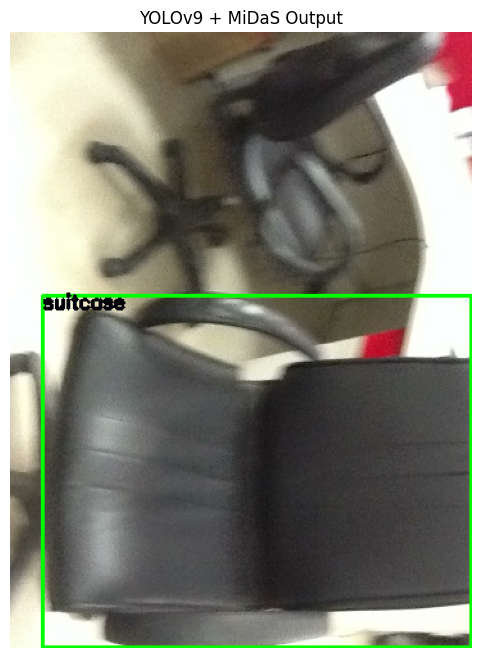

In [ ]:
# -------------------------------
# 6. Match YOLO boxes with depth
# -------------------------------


import matplotlib.pyplot as plt
print("Detected objects and estimated distances:\n")

for box in boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    label = class_names[int(box.cls[0])]
    confidence = float(box.conf[0])

    # Get depth crop from box
    depth_crop = depth_map_resized[y1:y2, x1:x2]
    if depth_crop.size > 0:
        avg_depth = depth_crop.mean()
        print(f"{label} ({confidence:.2f}) - Estimated distance: {avg_depth:.2f} (relative units)")
    else:
        print(f"{label} ({confidence:.2f}) - Depth not available")


for box in boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    label = class_names[int(box.cls[0])]
    cv2.rectangle(cv2_image, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(cv2_image, label, (x1, y1 + 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (9, 1, 1), 2)


# Convert image from BGR to RGB (OpenCV uses BGR by default)
cv2_image_rgb1 = cv2.cvtColor(cv2_image, cv2.COLOR_BGR2RGB)

# Show the image using matplotlib
plt.figure(figsize=(10, 8))
plt.imshow(cv2_image_rgb1)
plt.title("YOLOv9 + MiDaS Output")
plt.axis("off")
plt.show()
